# **User Analytics in the Telecommunication Industry**

## **3. Experience Analytics**

This notebook analyzes customer experience using network performance parameters and handset characteristics. The analysis focuses on TCP retransmission, Round Trip Time (RTT), throughput, and handset type to understand differences in user experience across customers.

### 3.1 **Required Libraries**

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Required libraries imported successfully.")

Required libraries imported successfully.


### **3.2 Load Telecom Dataset for Experience Analysis**

The telecom dataset is loaded to analyze network performance parameters and handset characteristics required for the Experience Analytics task.

In [ ]:
# Load the telecom dataset

file_path = '../data/raw/telcom_data.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (150001, 55)


### **3.3 Experience Metrics Identification**

In [ ]:
# Identify the key experience-related variables

experience_columns = [
    'TCP DL Retrans. Vol (Bytes)',
    'TCP UL Retrans. Vol (Bytes)',
    'Avg RTT DL (ms)',
    'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)',
    'Avg Bearer TP UL (kbps)',
    'Handset Type'
]

print("Experience-related columns:")
for column in experience_columns:
    print("-", column)

Experience-related columns:
- TCP DL Retrans. Vol (Bytes)
- TCP UL Retrans. Vol (Bytes)
- Avg RTT DL (ms)
- Avg RTT UL (ms)
- Avg Bearer TP DL (kbps)
- Avg Bearer TP UL (kbps)
- Handset Type


### **3.4 Missing Value Analysis**

In [ ]:
# Check missing values in experience-related variables

missing_values = df[experience_columns].isnull().sum()

missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Values': missing_values.values
})

missing_summary['Missing_Percentage'] = (
    missing_summary['Missing_Values'] / len(df) * 100
)

display(missing_summary)

,Column,Missing_Values,Missing_Percentage
0,TCP DL Retrans. Vol (Bytes),88146,58.763608
1,TCP UL Retrans. Vol (Bytes),96649,64.432237
2,Avg RTT DL (ms),27829,18.552543
3,Avg RTT UL (ms),27812,18.541210
4,Avg Bearer TP DL (kbps),1,0.000667
5,Avg Bearer TP UL (kbps),1,0.000667
6,Handset Type,572,0.381331


### **3.5 Missing Value Treatment**

Missing values in numerical experience variables are replaced with the corresponding column mean. Missing values in the categorical Handset Type variable are replaced with its mode.

In [ ]:
# Treat missing values in experience-related variables

# Numerical variables: replace missing values with column mean
numerical_experience_columns = [
    'TCP DL Retrans. Vol (Bytes)',
    'TCP UL Retrans. Vol (Bytes)',
    'Avg RTT DL (ms)',
    'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)',
    'Avg Bearer TP UL (kbps)'
]

for column in numerical_experience_columns:
    df[column] = df[column].fillna(df[column].mean())

# Categorical variable: replace missing values with mode
df['Handset Type'] = df['Handset Type'].fillna(df['Handset Type'].mode()[0])

print("Missing values treated successfully.")

Missing values treated successfully.


### **3.6 Missing Value Verification**

The experience-related variables are checked again after missing value treatment to confirm that no missing values remain.

In [ ]:
# Verify that missing values have been treated

remaining_missing = df[experience_columns].isnull().sum()

verification_summary = pd.DataFrame({
    'Column': remaining_missing.index,
    'Remaining_Missing_Values': remaining_missing.values
})

display(verification_summary)

,Column,Remaining_Missing_Values
0,TCP DL Retrans. Vol (Bytes),0
1,TCP UL Retrans. Vol (Bytes),0
2,Avg RTT DL (ms),0
3,Avg RTT UL (ms),0
4,Avg Bearer TP DL (kbps),0
5,Avg Bearer TP UL (kbps),0
6,Handset Type,0


### **3.7 Outlier Analysis**

Outliers in the numerical experience variables are identified using the Interquartile Range (IQR) method. The IQR method helps identify unusually high or low observations that may affect the analysis.

In [ ]:
# Identify outliers using the IQR method

outlier_summary = []

for column in numerical_experience_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,TCP DL Retrans. Vol (Bytes),1332932.0,2.080991e+07,1.947698e+07,-2.788254e+07,5.002539e+07,2525
1,TCP UL Retrans. Vol (Bytes),63009.0,7.596587e+05,6.966497e+05,-9.819655e+05,1.804633e+06,1320
2,Avg RTT DL (ms),35.0,1.097957e+02,7.479571e+01,-7.719356e+01,2.219893e+02,7718
3,Avg RTT UL (ms),3.0,1.766288e+01,1.466288e+01,-1.899432e+01,3.965721e+01,8975
4,Avg Bearer TP DL (kbps),43.0,1.971000e+04,1.966700e+04,-2.945750e+04,4.921050e+04,13235
5,Avg Bearer TP UL (kbps),47.0,1.120000e+03,1.073000e+03,-1.562500e+03,2.729500e+03,21531


### **3.8 Outlier Treatment**

The identified outliers in the numerical experience variables are replaced with the corresponding column mean, following the project preprocessing guideline.

In [ ]:
# Treat outliers by replacing them with the column mean

outlier_treatment_summary = []

for column in numerical_experience_columns:
    # Calculate IQR boundaries
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calculate original mean before replacing outliers
    column_mean = df[column].mean()

    # Identify outliers
    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    # Replace outliers with the column mean
    df.loc[outlier_mask, column] = column_mean

    outlier_treatment_summary.append({
        'Column': column,
        'Outliers_Replaced': outlier_count,
        'Replacement_Value_Mean': column_mean
    })

outlier_treatment_summary = pd.DataFrame(outlier_treatment_summary)

display(outlier_treatment_summary)

,Column,Outliers_Replaced,Replacement_Value_Mean
0,TCP DL Retrans. Vol (Bytes),2525,2.080991e+07
1,TCP UL Retrans. Vol (Bytes),1320,7.596587e+05
2,Avg RTT DL (ms),7718,1.097957e+02
3,Avg RTT UL (ms),8975,1.766288e+01
4,Avg Bearer TP DL (kbps),13235,1.330005e+04
5,Avg Bearer TP UL (kbps),21531,1.770429e+03


### **3.9 Outlier Treatment Verification**

The numerical experience variables are checked again after outlier treatment to confirm that the identified outliers have been replaced successfully.

In [ ]:
# Verify outlier treatment using the original IQR boundaries

verification_results = []

for _, row in outlier_summary.iterrows():
    column = row['Column']
    lower_bound = row['Lower_Bound']
    upper_bound = row['Upper_Bound']

    outlier_count_after_treatment = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    verification_results.append({
        'Column': column,
        'Original_Outliers': int(row['Outlier_Count']),
        'Remaining_Outliers': int(outlier_count_after_treatment)
    })

outlier_verification = pd.DataFrame(verification_results)

display(outlier_verification)

,Column,Original_Outliers,Remaining_Outliers
0,TCP DL Retrans. Vol (Bytes),2525,0
1,TCP UL Retrans. Vol (Bytes),1320,0
2,Avg RTT DL (ms),7718,0
3,Avg RTT UL (ms),8975,0
4,Avg Bearer TP DL (kbps),13235,0
5,Avg Bearer TP UL (kbps),21531,0


### 3.10 **Derived Experience Metrics**

The cleaned session-level data is used to create combined experience metrics for TCP retransmission, RTT, and throughput. These derived metrics will be aggregated at customer level in the next step.

In [ ]:
#### 3.10.1 Create Session-Level Experience Metrics

df['TCP Retransmission (Bytes)'] = (
    df['TCP DL Retrans. Vol (Bytes)'] +
    df['TCP UL Retrans. Vol (Bytes)']
)

df['RTT (ms)'] = (
    df['Avg RTT DL (ms)'] +
    df['Avg RTT UL (ms)']
) / 2

df['Throughput (kbps)'] = (
    df['Avg Bearer TP DL (kbps)'] +
    df['Avg Bearer TP UL (kbps)']
) / 2

print("Combined experience metrics created successfully.")

Combined experience metrics created successfully.


The derived TCP retransmission, RTT, and throughput metrics are calculated at the session level. These metrics will be aggregated per customer using the MSISDN identifier to obtain the required customer-level experience metrics.

###3.10.2 **Customer-Level Experience Metrics**

The session-level experience metrics are aggregated per customer using the MSISDN identifier. For each customer, the analysis calculates average TCP retransmission, average RTT, most frequently used handset type, and average throughput.

The handset type is retained for handset-level analysis, while the three numerical experience metrics — Average TCP Retransmission, Average RTT, and Average Throughput — are used as the features for experience-based K-Means clustering.

In [ ]:
# Aggregate experience metrics at customer level

# Keep only records with a valid customer identifier
experience_df = df.dropna(subset=['MSISDN/Number']).copy()

# Aggregate numerical experience metrics and most frequently used handset type
experience_data = (
    experience_df
    .groupby('MSISDN/Number')
    .agg(
        Average_TCP_Retransmission=('TCP Retransmission (Bytes)', 'mean'),
        Average_RTT=('RTT (ms)', 'mean'),
        Handset_Type=('Handset Type', lambda x: x.mode().iloc[0]),
        Average_Throughput=('Throughput (kbps)', 'mean')
    )
    .reset_index()
)

# Display basic information about the customer-level dataset
print("Customer-level experience metrics created successfully.")
print("Number of customers:", experience_data['MSISDN/Number'].nunique())
print("Shape:", experience_data.shape)

display(experience_data.head(10))

Customer-level experience metrics created successfully.
Number of customers: 106856
Shape: (106856, 5)


,MSISDN/Number,Average_TCP_Retransmission,Average_RTT,Handset_Type,Average_Throughput
0,3.360100e+10,2.156957e+07,23.000000,Huawei P20 Lite Huawei Nova 3E,38.000000
1,3.360100e+10,2.156957e+07,15.500000,Apple iPhone 7 (A1778),49.500000
2,3.360100e+10,2.156957e+07,63.729294,undefined,48.500000
3,3.360101e+10,7.607247e+05,42.000000,Apple iPhone 5S (A1457),124.000000
4,3.360101e+10,1.547020e+07,29.750000,Apple iPhone Se (A1723),10551.357162
5,3.360101e+10,1.116600e+07,37.864647,Samsung Galaxy A8 (2018),1977.000000
6,3.360101e+10,1.083990e+07,13.250000,Huawei Mate 10 Pro Porsche Design Huawei Mate 10,10628.250000
7,3.360101e+10,7.599367e+05,26.000000,Samsung Galaxy S8 Plus (Sm-G955F),623.500000
8,3.360101e+10,2.156957e+07,63.729294,undefined,47.250000
9,3.360102e+10,2.081121e+07,31.000000,Apple iPhone X (A1865),73.000000


In [ ]:
# Validate customer-level experience dataset

print("Customer-level experience dataset validation")
print("-" * 50)

# Check duplicate customer IDs
duplicate_customers = experience_data['MSISDN/Number'].duplicated().sum()

# Check missing values in customer-level metrics
missing_values = experience_data[
    [
        'Average_TCP_Retransmission',
        'Average_RTT',
        'Handset_Type',
        'Average_Throughput'
    ]
].isna().sum()

# Display validation results
print("Duplicate customer IDs:", duplicate_customers)
print("\nMissing values:")
display(missing_values)

print("\nFinal customer-level dataset shape:", experience_data.shape)

Customer-level experience dataset validation
--------------------------------------------------
Duplicate customer IDs: 0

Missing values:


Average_TCP_Retransmission    0
Average_RTT                   0
Handset_Type                  0
Average_Throughput            0
dtype: int64


Final customer-level dataset shape: (106856, 5)


### 3.11 **Top, Bottom, and Most Frequent Experience Values**

To understand the distribution of network experience parameters, the top 10, bottom 10, and most frequent 10 values are computed for TCP retransmission, RTT, and throughput. These statistics help identify extreme values as well as the most commonly observed network conditions in the dataset.

In [ ]:
# Compute top 10, bottom 10, and most frequent 10 values
# for TCP retransmission, RTT, and throughput

experience_metrics = {
    'TCP Retransmission (Bytes)': 'TCP Retransmission (Bytes)',
    'RTT (ms)': 'RTT (ms)',
    'Throughput (kbps)': 'Throughput (kbps)'
}

experience_value_results = {}

for metric_name, column_name in experience_metrics.items():

    top_10 = (
        df[column_name]
        .nlargest(10)
        .reset_index(drop=True)
        .to_frame(name=metric_name)
    )

    bottom_10 = (
        df[column_name]
        .nsmallest(10)
        .reset_index(drop=True)
        .to_frame(name=metric_name)
    )

    most_frequent_10 = (
        df[column_name]
        .value_counts()
        .head(10)
        .rename_axis(metric_name)
        .reset_index(name='Frequency')
    )

    experience_value_results[metric_name] = {
        'Top 10': top_10,
        'Bottom 10': bottom_10,
        'Most Frequent 10': most_frequent_10
    }

    print(f"\n{'=' * 60}")
    print(metric_name)
    print('=' * 60)

    print("\nTop 10 Values:")
    display(top_10)

    print("\nBottom 10 Values:")
    display(bottom_10)

    print("\nMost Frequent 10 Values:")
    display(most_frequent_10)


TCP Retransmission (Bytes)

Top 10 Values:


,TCP Retransmission (Bytes)
0,5.168390e+07
1,5.062927e+07
2,5.060485e+07
3,5.047944e+07
4,5.039288e+07
5,5.035950e+07
6,5.034698e+07
7,5.031799e+07
8,5.025940e+07
9,5.023159e+07



Bottom 10 Values:


,TCP Retransmission (Bytes)
0,86.0
1,97.0
2,106.0
3,108.0
4,113.0
5,128.0
6,129.0
7,134.0
8,134.0
9,143.0



Most Frequent 10 Values:


...

,Throughput (kbps)
0,25922.0
1,25895.0
2,25865.0
3,25847.5
4,25837.5
5,25794.0
6,25766.5
7,25756.5
8,25736.5
9,25720.0



Bottom 10 Values:


,Throughput (kbps)
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0



Most Frequent 10 Values:


,Throughput (kbps),Frequency
0,7535.237287,7965
1,31.500000,3886
2,7.500000,3741
3,48.500000,1945
4,45.000000,1885
5,49.000000,1801
6,48.000000,1671
7,49.500000,1571
8,44.500000,1557
9,45.500000,1520


### **Note on Session-Level and Customer-Level Analysis**

The customer-level aggregation above was performed to obtain the required experience metrics for each customer, including average TCP retransmission, average RTT, handset type, and average throughput.

For the next analysis, the cleaned session-level dataset is used to compute the top 10, bottom 10, and most frequent 10 values of TCP retransmission, RTT, and throughput. This allows us to understand the overall distribution and common network conditions across individual sessions before moving to handset-level analysis and customer experience clustering.

## **Key Insights from Experience Metrics**

### 1. TCP Retransmission – Top 10 Values
- The highest observed TCP retransmission value in the cleaned session-level dataset is approximately **51.68 million bytes**.
- These high values represent sessions with relatively large amounts of retransmitted TCP data.
- High TCP retransmission can indicate greater retransmission activity during network communication.
- The values should be interpreted in the context of the preprocessing and derived TCP retransmission metric.

### 2. TCP Retransmission – Bottom 10 Values
- The lowest TCP retransmission value is approximately **86 bytes**.
- These observations represent sessions with very low TCP retransmission.
- The wide difference between the lowest and highest values indicates substantial variation in TCP retransmission across sessions.

### 3. TCP Retransmission – Most Frequent 10 Values
- The most frequently occurring TCP retransmission value is approximately **21.57 million bytes**, with a frequency of **85,640**.
- This repeated value is mainly related to the mean-based treatment of missing values during preprocessing.
- Therefore, this high frequency should be interpreted as a preprocessing effect rather than evidence that all these sessions naturally had identical TCP retransmission.

### 4. RTT – Top 10 Values
- The highest observed RTT value in the cleaned session-level dataset is approximately **130 ms**.
- Higher RTT values represent comparatively longer network response times.
- The top values are relatively close to each other, indicating that the highest RTT observations are concentrated within a limited range.

### 5. RTT – Bottom 10 Values
- The lowest RTT observations include multiple **0 ms** values along with very small values such as **1 ms, 2 ms, 2.5 ms and 3 ms**.
- These observations represent sessions with very low measured round-trip time.
- The presence of both very low and higher RTT values indicates variation in network response conditions.

### 6. RTT – Most Frequent 10 Values
- The most frequently observed RTT value is approximately **63.73 ms**, occurring **27,806 times**.
- Other frequently occurring values include **14.5 ms, 19.5 ms, 19 ms and 20 ms**.
- This indicates that several RTT levels occur repeatedly across the cleaned session-level dataset.

### 7. Throughput – Top 10 Values
- The highest observed throughput value is approximately **25,922 kbps**.
- These high values represent sessions with relatively high observed data transfer rates.
- The top throughput observations are concentrated in the range of approximately **25,700–25,900 kbps**.
- This indicates that some sessions achieved considerably higher throughput than the lower-throughput observations.

### 8. Throughput – Bottom 10 Values
- The bottom 10 throughput values include multiple **0 kbps** observations.
- These values represent sessions with little or no measured data transfer rate.
- The difference between the lowest and highest throughput values indicates substantial variation in observed network performance.

### 9. Throughput – Most Frequent 10 Values
- The most frequently observed throughput value is approximately **7,535.24 kbps**, occurring **7,965 times**.
- Other frequently occurring values include **31.5 kbps, 7.5 kbps, 48.5 kbps, 45 kbps and 49 kbps**.
- These repeated values show that certain throughput levels occur frequently across the cleaned session-level dataset.

### Overall Experience Insight
- TCP retransmission, RTT and throughput show considerable variation across network sessions.
- TCP retransmission ranges from very low values to more than 51 million bytes, while RTT ranges from 0 ms to approximately 130 ms.
- Throughput ranges from 0 kbps to approximately 25,922 kbps.
- These experience metrics provide a foundation for analysing differences across handset types and for customer-level experience clustering.
- Since missing values and outliers were treated according to the project methodology, the findings should be interpreted as patterns in the **cleaned dataset**.

## 3.12 **Handset-Level Experience Analysis**

This section analyzes network experience across different handset types. The analysis focuses on average throughput and average TCP retransmission to identify differences in network performance across handset categories.

### 3.12.1 Distribution of Average Throughput per Handset Type

The distribution of customer-level average throughput is examined across handset types using a boxplot. To maintain readability, the analysis focuses on the 10 most frequently observed handset types in the customer-level experience dataset.

Numerical Summary of Average Throughput by Handset Type:


,Count,Mean,Median,Minimum,Maximum
Handset_Type,,,,,
Huawei B528S-23A,10615,11758.05,11101.21,0.0,25837.50
Samsung Galaxy S8 (Sm-G950F),3245,3710.08,68.00,0.0,25469.50
Apple iPhone 7 (A1778),4699,2639.50,58.50,0.0,25720.00
undefined,6669,2419.95,54.50,0.0,25497.50
Apple iPhone 6 (A1586),6260,2385.58,58.00,0.0,25577.50
Apple iPhone Xr (A2105),3072,2247.80,56.00,0.0,25612.50
Apple iPhone 8 (A1905),3543,2185.96,57.88,0.0,25428.21
Apple iPhone Se (A1723),3754,1891.83,54.00,0.0,25711.50
Apple iPhone 6S (A1688),6759,1868.74,53.50,0.0,25267.00


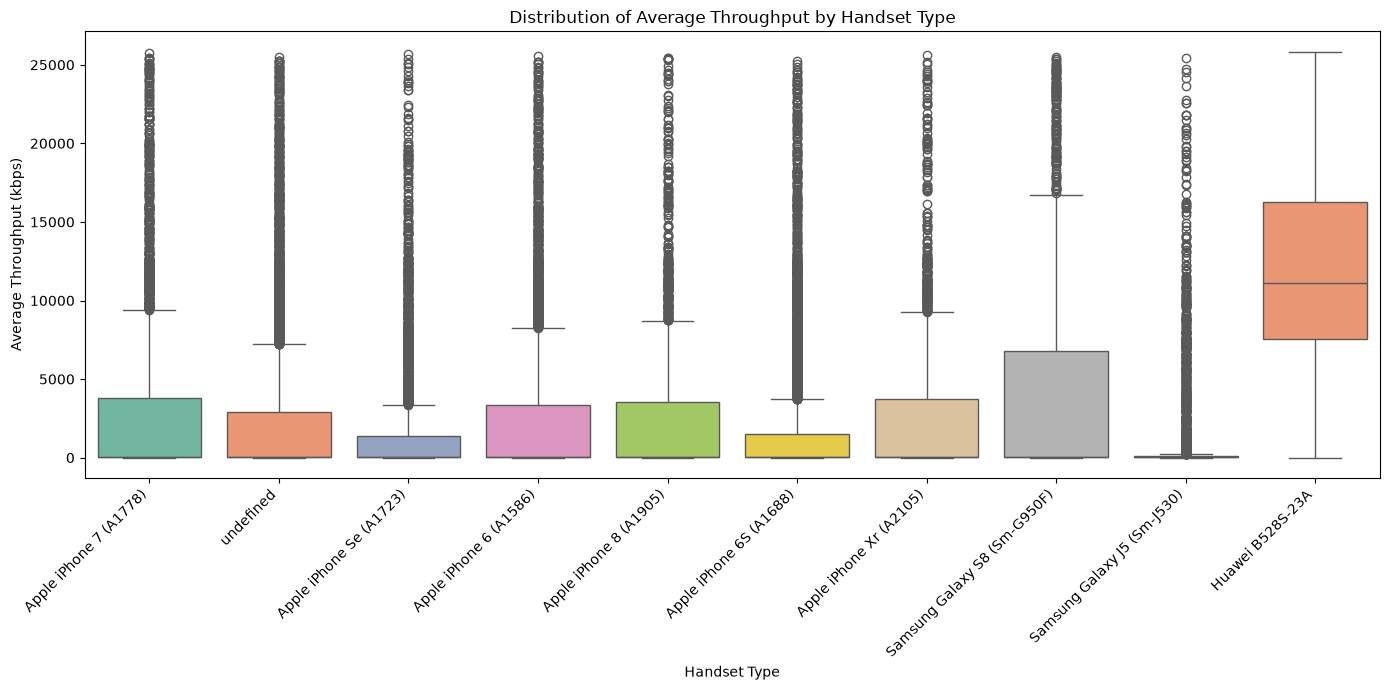

In [ ]:
# Distribution of average throughput by handset type

# Select the 10 most frequently used handset types
top_handsets = (
    experience_data['Handset_Type']
    .value_counts()
    .head(10)
    .index
)

throughput_handset_data = experience_data[
    experience_data['Handset_Type'].isin(top_handsets)
].copy()


# Create numerical summary for the selected handset types
throughput_summary = (
    throughput_handset_data
    .groupby('Handset_Type')['Average_Throughput']
    .agg(
        Count='count',
        Mean='mean',
        Median='median',
        Minimum='min',
        Maximum='max'
    )
    .sort_values('Mean', ascending=False)
)

print("Numerical Summary of Average Throughput by Handset Type:")
display(throughput_summary.round(2))


# Plot distribution of average throughput
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=throughput_handset_data,
    x='Handset_Type',
    y='Average_Throughput',
    palette='Set2',
    hue='Handset_Type',
    legend=False
)

plt.title('Distribution of Average Throughput by Handset Type')
plt.xlabel('Handset Type')
plt.ylabel('Average Throughput (kbps)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Insights

- **Huawei B528S-23A** shows the highest average throughput among the selected handset types, with a mean throughput of approximately **11,758.05 kbps** and a median of **11,101.21 kbps**.

- **Samsung Galaxy S8 (Sm-G950F)** has a mean throughput of approximately **3,710.08 kbps**, while its median throughput is **68.00 kbps**, indicating a wide difference between typical and higher-throughput observations.

- The selected **Apple iPhone models** show mean throughput values ranging from approximately **1,868.74 kbps to 2,639.50 kbps**, with medians close to **53.50–58.50 kbps**.

- **Samsung Galaxy J5 (Sm-J530)** has the lowest mean throughput among the selected handset types at approximately **1,240.64 kbps**, with a median of **39.00 kbps**.

- The difference between mean and median throughput for several handset types indicates that the distributions are strongly spread and contain higher-throughput observations.

- The boxplot and summary statistics together show noticeable differences in throughput distribution across handset types. These differences represent observed associations in the dataset and should **not be interpreted as evidence that the handset itself causes the throughput differences**.

- These handset-level throughput patterns provide useful context for the subsequent **TCP retransmission analysis and experience-based customer segmentation**.

### 3.12.2 **Average TCP Retransmission per Handset Type**

The average TCP retransmission is compared across the 10 most frequently observed handset types in the customer-level experience dataset. This analysis helps examine whether the observed level of TCP retransmission differs across handset categories.

,Handset_Type,Average_TCP_Retransmission
0,Samsung Galaxy J5 (Sm-J530),1.834821e+07
1,Apple iPhone 6S (A1688),1.785052e+07
2,Apple iPhone Xr (A2105),1.781017e+07
3,Apple iPhone Se (A1723),1.760655e+07
4,Apple iPhone 8 (A1905),1.740364e+07
5,Apple iPhone 6 (A1586),1.656792e+07
6,undefined,1.655264e+07
7,Apple iPhone 7 (A1778),1.631251e+07
8,Samsung Galaxy S8 (Sm-G950F),1.495230e+07
9,Huawei B528S-23A,9.218110e+06


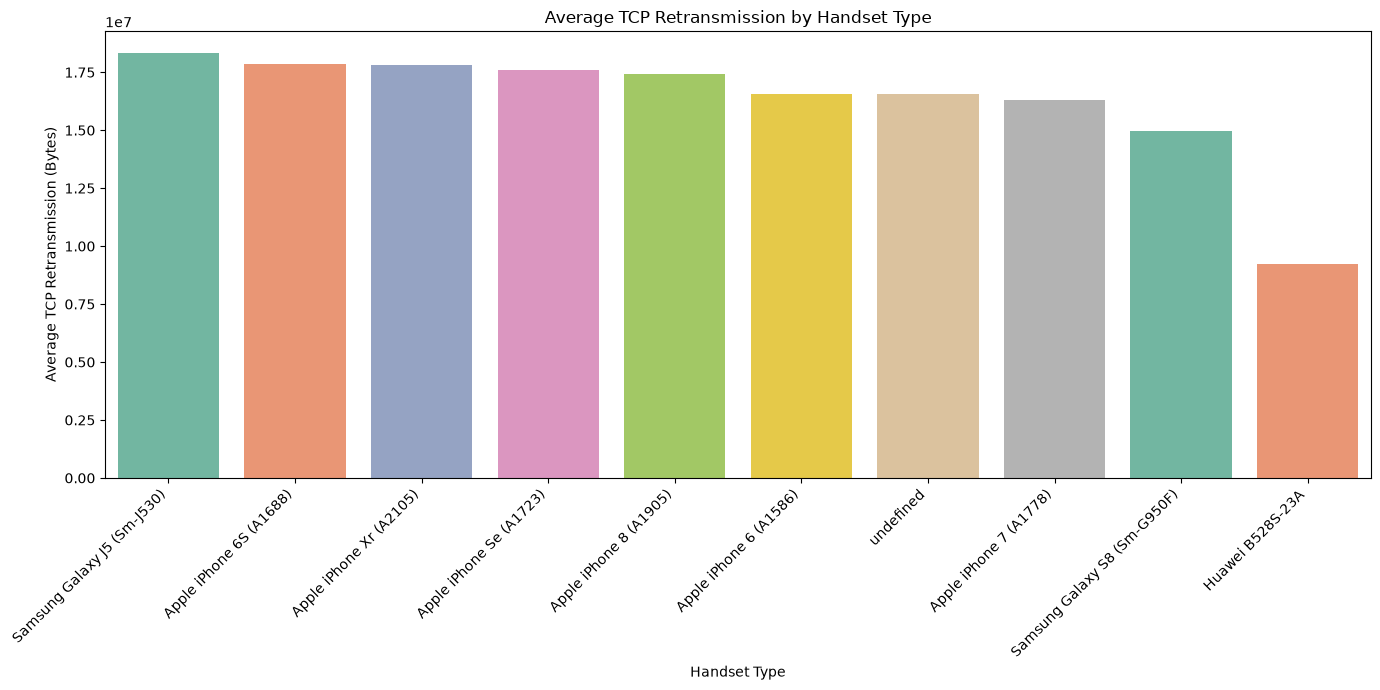

In [ ]:
# Average TCP retransmission by handset type

# Select the 10 most frequently used handset types
top_handsets = (
    experience_data['Handset_Type']
    .value_counts()
    .head(10)
    .index
)

tcp_handset_data = experience_data[
    experience_data['Handset_Type'].isin(top_handsets)
].copy()

# Calculate average TCP retransmission for each handset type
tcp_handset_summary = (
    tcp_handset_data
    .groupby('Handset_Type')['Average_TCP_Retransmission']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Display summary table
display(tcp_handset_summary)

# Plot average TCP retransmission by handset type
plt.figure(figsize=(14, 7))

sns.barplot(
    data=tcp_handset_summary,
    x='Handset_Type',
    y='Average_TCP_Retransmission',
    hue='Handset_Type',
    palette='Set2',
    legend=False
)

plt.title('Average TCP Retransmission by Handset Type')
plt.xlabel('Handset Type')
plt.ylabel('Average TCP Retransmission (Bytes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Insights – Average TCP Retransmission by Handset Type

- The average TCP retransmission varies across the selected handset types, indicating differences in the observed amount of retransmitted TCP data across handset categories.

- **Samsung Galaxy J5 (Sm-J530)** shows the highest average TCP retransmission among the selected handset types, at approximately **1.83 × 10⁷ bytes**.

- Most of the selected **Apple iPhone models** show relatively similar average TCP retransmission values, generally within the range of approximately **1.6 × 10⁷ to 1.8 × 10⁷ bytes**.

- **Samsung Galaxy S8 (Sm-G950F)** has an average TCP retransmission of approximately **1.50 × 10⁷ bytes**, which is lower than several of the selected Apple iPhone models.

- **Huawei B528S-23A** shows the lowest average TCP retransmission among the selected handset types, at approximately **9.22 × 10⁶ bytes**.

- The difference between the highest and lowest handset-level averages indicates that the observed TCP retransmission level varies across handset categories.

- These results describe differences in observed TCP retransmission by handset type; they do not establish that the handset model itself causes the difference.

- When combined with the throughput analysis, handset-level TCP retransmission provides an additional perspective for understanding variations in customer network experience.

## 3.13 **Experience-Based User Segmentation**

The previous analyses examined user experience through TCP retransmission, RTT, throughput, and handset type. To further understand different experience patterns across customers, the three numerical experience metrics — Average TCP Retransmission, Average RTT, and Average Throughput — will be used for K-Means clustering.

As specified in the project guideline, K-Means clustering will be performed with **K = 3** to segment customers into three experience groups. The resulting clusters will then be compared using their experience metrics to provide a brief description of each customer experience group.

### 3.13.1 **Standardize Experience Metrics**

To ensure that TCP Retransmission, RTT, and Throughput contribute fairly to the clustering process, the customer-level experience metrics are standardized using StandardScaler.

The three metrics used for clustering are:
- Average TCP Retransmission
- Average RTT
- Average Throughput

In [ ]:
# Select customer-level experience metrics for clustering
experience_features = [
    'Average_TCP_Retransmission',
    'Average_RTT',
    'Average_Throughput'
]

# Standardize the experience metrics
scaler = StandardScaler()

experience_scaled = scaler.fit_transform(
    experience_data[experience_features]
)

# Convert standardized values into a DataFrame
experience_scaled_df = pd.DataFrame(
    experience_scaled,
    columns=experience_features,
    index=experience_data.index
)

print("Experience metrics standardized successfully.")
print("Shape of standardized data:", experience_scaled_df.shape)

experience_scaled_df.head()

Experience metrics standardized successfully.
Shape of standardized data: (106856, 3)


,Average_TCP_Retransmission,Average_RTT,Average_Throughput
0,0.752646,-0.744891,-0.647710
1,0.752646,-1.096775,-0.645725
2,0.752646,1.166040,-0.645897
3,-1.561837,0.146548,-0.632864
4,0.074238,-0.428196,1.167130


### 3.13.2 **K-Means Clustering of Customer Experience**

K-Means clustering is applied to the standardized customer-level experience metrics. As specified in the project guideline, three clusters (K = 3) are created to segment customers into distinct experience groups.

In [ ]:
# Apply K-Means clustering with K = 3
kmeans_experience = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_data['Experience_Cluster'] = kmeans_experience.fit_predict(
    experience_scaled_df
)

# Display the number of customers in each cluster
cluster_counts = (
    experience_data['Experience_Cluster']
    .value_counts()
    .sort_index()
)

print("Customer count in each experience cluster:")
print(cluster_counts)

Customer count in each experience cluster:
Experience_Cluster
0    43998
1    35909
2    26949
Name: count, dtype: int64


### 3.13.3 **Experience Cluster Summary**

The clusters are compared using the original, non-standardized experience metrics to understand the actual network experience characteristics of each customer group.

In [ ]:
# Calculate cluster-wise statistics using the original metrics
experience_cluster_summary = (
    experience_data
    .groupby('Experience_Cluster')
    .agg(
        Customers=('MSISDN/Number', 'count'),
        Min_TCP_Retransmission=('Average_TCP_Retransmission', 'min'),
        Max_TCP_Retransmission=('Average_TCP_Retransmission', 'max'),
        Mean_TCP_Retransmission=('Average_TCP_Retransmission', 'mean'),
        Min_RTT=('Average_RTT', 'min'),
        Max_RTT=('Average_RTT', 'max'),
        Mean_RTT=('Average_RTT', 'mean'),
        Min_Throughput=('Average_Throughput', 'min'),
        Max_Throughput=('Average_Throughput', 'max'),
        Mean_Throughput=('Average_Throughput', 'mean')
    )
    .reset_index()
)

experience_cluster_summary

,Experience_Cluster,Customers,Min_TCP_Retransmission,Max_TCP_Retransmission,Mean_TCP_Retransmission,Min_RTT,Max_RTT,Mean_RTT,Min_Throughput,Max_Throughput,Mean_Throughput
0,0,43998,2.860151e+06,50604849.0,2.037487e+07,0.0,43.0,21.611608,0.5,25307.714323,778.722044
1,1,35909,9.700000e+01,37201538.0,3.895633e+06,8.0,121.5,41.075753,0.5,25837.500000,9375.239526
2,2,26949,1.820000e+02,50259399.0,2.023900e+07,41.5,129.0,64.133368,0.0,25320.714323,1264.824759


In [ ]:
# Display the mean experience metrics for each cluster
experience_cluster_means = (
    experience_data
    .groupby('Experience_Cluster')[
        [
            'Average_TCP_Retransmission',
            'Average_RTT',
            'Average_Throughput'
        ]
    ]
    .mean()
    .reset_index()
)

experience_cluster_means

,Experience_Cluster,Average_TCP_Retransmission,Average_RTT,Average_Throughput
0,0,2.037487e+07,21.611608,778.722044
1,1,3.895633e+06,41.075753,9375.239526
2,2,2.023900e+07,64.133368,1264.824759


3.13.5 Key Insights – Experience-Based User Segmentation

- Cluster 1 shows stronger network experience characteristics, with the lowest mean TCP retransmission of approximately 3.90 million bytes and the highest mean throughput of approximately 9,375.24 kbps. Its mean RTT is approximately 41.08 ms.

- Cluster 0 shows a mixed experience profile, with the lowest mean RTT of approximately 21.61 ms but high mean TCP retransmission of approximately 20.37 million bytes and the lowest mean throughput of approximately 778.72 kbps.

- Cluster 2 shows relatively weaker network experience characteristics, with high mean TCP retransmission of approximately 20.24 million bytes, the highest mean RTT of approximately 64.13 ms, and relatively low mean throughput of approximately 1,264.82 kbps.

- The three clusters represent different combinations of TCP retransmission, RTT, and throughput. These experience segments can be used in the next task to compare customer engagement and network experience.

In [ ]:
# Final validation of the experience clustering results

print("Total customers:", experience_data['MSISDN/Number'].nunique())
print("Number of experience clusters:", experience_data['Experience_Cluster'].nunique())
print("\nExperience cluster counts:")
print(experience_data['Experience_Cluster'].value_counts().sort_index())

Total customers: 106856
Number of experience clusters: 3

Experience cluster counts:
Experience_Cluster
0    43998
1    35909
2    26949
Name: count, dtype: int64


### 3.13.6 Overall Experience Analytics Conclusion

The experience analysis provides a customer-level view of network quality using TCP retransmission, RTT, throughput, and handset information. After cleaning and aggregating the session-level data, customers were segmented into three experience groups using K-Means clustering with K = 3.

Cluster 1 shows stronger throughput and lower TCP retransmission characteristics, while Cluster 0 has a mixed experience profile and Cluster 2 shows relatively weaker network experience characteristics based on the observed experience metrics.

These experience segments provide the foundation for the next stage of the analysis, where customer engagement and network experience will be combined to evaluate overall customer satisfaction.

In [ ]:
# Save the final customer-level experience data for Task 4

import os

os.makedirs('../outputs', exist_ok=True)

experience_data.to_csv(
    '../outputs/user_experience_metrics.csv',
    index=False
)

print("Experience metrics saved successfully.")
print("Shape:", experience_data.shape)
print("File:", '../outputs/user_experience_metrics.csv')

Experience metrics saved successfully.
Shape: (106856, 6)
File: ../outputs/user_experience_metrics.csv
